In [3]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [4]:
# Set seed for reproducibility
np.random.seed(42)

# -----------------------------------------------------------------------------
# STEP 1: Simulate Astronomical Images (Science & Reference)
# -----------------------------------------------------------------------------
def gaussian_psf(shape, sigma):
    """Generate a 2D Gaussian PSF kernel."""
    m, n = shape
    y, x = np.mgrid[-m//2 + 1:m//2 + 1, -n//2 + 1:n//2 + 1]
    g = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    return g / g.sum()

# Frame size
grid_size = (64, 64)

# Create baseline sky background and static sources (stars/galaxies)
sky_background = 500.0  # background limited regime (Poisson noise)
true_sky = np.full(grid_size, sky_background)

# Add 3 static stars
true_sky[20, 20] += 5000.0
true_sky[45, 15] += 8000.0
true_sky[30, 50] += 12000.0

# Add a fast transient (e.g., Kilonova or Supernova) present ONLY in Science image
transient_sky = true_sky.copy()
transient_sky[40, 40] += 6000.0  # Transient signal

# Create PSFs (Reference image has better seeing than Science image)
psf_ref = gaussian_psf((15, 15), sigma=1.2)   # Seeing = 1.2 px
psf_sci = gaussian_psf((15, 15), sigma=2.5)   # Seeing = 2.5 px

# Convolve sky models with respective PSFs
img_ref_ideal = fftconvolve(true_sky, psf_ref, mode='same')
img_sci_ideal = fftconvolve(transient_sky, psf_sci, mode='same')

# Add Poisson noise to simulate detector observations
img_ref = np.random.poisson(img_ref_ideal).astype(float)
img_sci = np.random.poisson(img_sci_ideal).astype(float)


Classifier Accuracy: 100.00%
Confusion Matrix:
 [[159   0]
 [  0 141]]


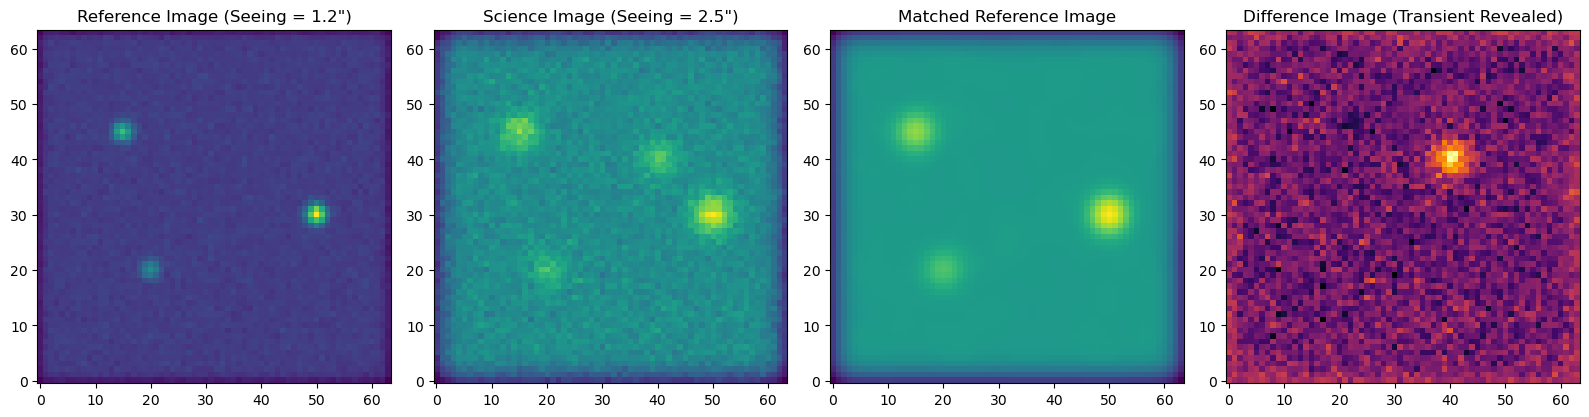

In [5]:


# -----------------------------------------------------------------------------
# STEP 2: Difference Imaging (PSF Matching Kernel K)
# -----------------------------------------------------------------------------
# To subtract reference from science, we convolve reference with a matching kernel K
# such that: PSF_ref * K ≈ PSF_sci.
# For simple Gaussian PSFs: sigma_kernel = sqrt(sigma_sci^2 - sigma_ref^2)
sigma_k = np.sqrt(2.5**2 - 1.2**2)
kernel_K = gaussian_psf((15, 15), sigma=sigma_k)

# Match reference image to science image seeing
img_ref_matched = fftconvolve(img_ref, kernel_K, mode='same')

# Difference Image Subtraction
diff_img = img_sci - img_ref_matched

# -----------------------------------------------------------------------------
# STEP 3: Real-Bogus Feature Extraction & Machine Learning Classification
# -----------------------------------------------------------------------------
def extract_features(stamp):
    """Extract basic topological/photometric features from a 9x9 image stamp."""
    peak = np.max(stamp)
    mean = np.mean(stamp)
    std = np.std(stamp)
    sum_flux = np.sum(stamp)
    # Simple central concentration feature
    center_flux = np.sum(stamp[3:6, 3:6])
    ratio = center_flux / (sum_flux + 1e-5)
    return [peak, mean, std, sum_flux, ratio]

# Generate synthetic dataset of 1,000 Real & Bogus stamps
X, y = [], []

for _ in range(500):
    # Real Source: Gaussian PSF profile + noise
    real_stamp = fftconvolve(gaussian_psf((9, 9), sigma=1.5) * 2000, 
                             gaussian_psf((9, 9), sigma=0.5), mode='same')
    real_stamp += np.random.normal(0, 50, (9, 9))
    X.append(extract_features(real_stamp))
    y.append(1) # Real

    # Bogus Artifact: Dipole, Cosmic Ray hit, or Single-pixel spike
    bogus_type = np.random.choice(['spike', 'dipole'])
    bogus_stamp = np.random.normal(0, 50, (9, 9))
    if bogus_type == 'spike':
        bogus_stamp[4, 4] += 3000.0 # Hot pixel hit
    else:
        bogus_stamp[3, 4] += 1500.0 # Registration dipole residual
        bogus_stamp[5, 4] -= 1500.0
    X.append(extract_features(bogus_stamp))
    y.append(0) # Bogus

X, y = np.array(X), np.array(y)

# Train Real/Bogus Classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

# Evaluate model
y_pred = clf.predict(X_test)
print(f"Classifier Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plotting the Results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_ref, cmap='viridis', origin='lower')
axes[0].set_title("Reference Image (Seeing = 1.2\")")
axes[1].imshow(img_sci, cmap='viridis', origin='lower')
axes[1].set_title("Science Image (Seeing = 2.5\")")
axes[2].imshow(img_ref_matched, cmap='viridis', origin='lower')
axes[2].set_title("Matched Reference Image")
axes[3].imshow(diff_img, cmap='inferno', origin='lower')
axes[3].set_title("Difference Image (Transient Revealed)")
plt.tight_layout()
plt.show()